In [49]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

X = pd.read_csv('X_feature.csv').values
y = pd.read_csv('y_churn.csv').values

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=84)

scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)
X_train_scaled = scaler.transform(X_train)

In [51]:
model_lr = LogisticRegression(class_weight='balanced')
model_lr.fit(X_train_scaled, y_train.flatten())
lr_predict = model_lr.predict(X_test_scaled)
lr_score = accuracy_score(y_test, lr_predict)
print(f"Logistics Scores: {lr_score:.3f}")
print("\nDetailed Report:\n", classification_report(y_test, lr_predict))
print(f"-> Model Coefficient {model_lr.coef_}")
cm = confusion_matrix(y_test, lr_predict)
print("\nThis is the Confusion Matrix\n", cm)

Logistics Scores: 0.921

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.91      0.98      0.94      1194
         1.0       0.95      0.82      0.88       668

    accuracy                           0.92      1862
   macro avg       0.93      0.90      0.91      1862
weighted avg       0.92      0.92      0.92      1862

-> Model Coefficient [[-0.41770226 -0.02186805  0.00569658 -0.59581728  0.07655618 -0.05394445
  -0.24273982  0.09621965  0.07118776  3.60349842]]

This is the Confusion Matrix
 [[1168   26]
 [ 122  546]]


In [112]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=5,
    random_state=84,
    use_label_encoder=True,
    eval_metric='logloss'
)


xgb_model.fit(X_train_scaled, y_train)
xgb_predict = xgb_model.predict(X_test_scaled)
xgb_accuracy = accuracy_score(y_test, xgb_predict)
print(f"XGBoost Scores: {xgb_accuracy:.3f}")
print("\nDetailed Report:\n", classification_report(y_test, xgb_predict))
cm = confusion_matrix(y_test, xgb_predict)
print("\nThis is the Confusion Matrix\n", cm)

c:\Users\HP\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:32:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Scores: 0.914

Detailed Report:
               precision    recall  f1-score   support

         0.0       0.91      0.97      0.94      1194
         1.0       0.93      0.82      0.87       668

    accuracy                           0.91      1862
   macro avg       0.92      0.89      0.90      1862
weighted avg       0.92      0.91      0.91      1862


This is the Confusion Matrix
 [[1155   39]
 [ 121  547]]


<Figure size 1000x600 with 0 Axes>

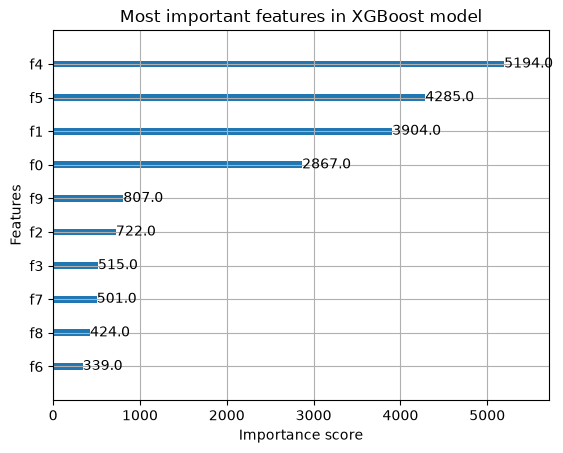

In [113]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='weight')
plt.title("Most important features in XGBoost model")
plt.show()